In [1]:
import pandas as pd

df = pd.read_parquet("data/Curve/3crv_transfer_events_full.parquet")
print(df.head())
print(df.columns)
print(df.dtypes)


   blockNumber                 timestamp  \
0     10809467 2020-09-06 17:55:46+00:00   
1     10810138 2020-09-06 20:19:35+00:00   
2     10810160 2020-09-06 20:25:22+00:00   
3     10810164 2020-09-06 20:26:14+00:00   
4     10810170 2020-09-06 20:27:20+00:00   

                                              txHash  logIndex  \
0  0xa7d90e460bed56181e41b74d143ec98fe097c8391700...       197   
1  0x4267679c0c5f326bf78cb4c0b3d7a17e13c0da4c4e61...       130   
2  0xc04212123f14220f642dc96f78c9b421d19bd67eb920...        77   
3  0x348c89c863d75e8607f47e29efb5cc363b548394bcef...       122   
4  0xcdb08cd6e0a960ecd9976935098bb3d3f48ac2d6aa91...        52   

                                         from  \
0  0x0000000000000000000000000000000000000000   
1  0x0000000000000000000000000000000000000000   
2  0xbf7d65d769e82e7b862df338223263ba33f72623   
3  0xbf7d65d769e82e7b862df338223263ba33f72623   
4  0xbf7d65d769e82e7b862df338223263ba33f72623   

                                           

In [5]:
import os
import time
from collections import defaultdict

import pandas as pd
from web3 import Web3
from dotenv import load_dotenv

load_dotenv()

ZERO = "0x0000000000000000000000000000000000000000"

RPC_URL = os.getenv("ETH_RPC_URL")
if not RPC_URL:
    raise RuntimeError("Missing ETH_RPC_URL")

w3 = Web3(Web3.HTTPProvider(RPC_URL))

df = pd.read_parquet("data/Curve/3crv_transfer_events_full.parquet").copy()

required_cols = ["from", "to", "value_3crv"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing required columns: {missing}")

df["from"] = df["from"].astype(str).str.lower()
df["to"] = df["to"].astype(str).str.lower()
df["value_3crv"] = pd.to_numeric(df["value_3crv"], errors="coerce").fillna(0.0)

# keep only valid-looking rows
df = df.dropna(subset=["from", "to", "value_3crv"]).copy()

balances = defaultdict(float)

# use plain tuples to avoid pandas renaming issues with column name 'from'
for frm, to, val in df[["from", "to", "value_3crv"]].itertuples(index=False, name=None):
    if frm != ZERO:
        balances[frm] -= float(val)
    if to != ZERO:
        balances[to] += float(val)

holders = pd.DataFrame(
    [{"address": a, "balance_3crv": b} for a, b in balances.items() if b > 1e-12]
)

if holders.empty:
    raise RuntimeError("No positive-balance holders found.")

holders = holders.sort_values("balance_3crv", ascending=False).reset_index(drop=True)

_code_cache = {}

def classify_address(addr: str) -> str:
    addr = str(addr).lower()

    if addr == ZERO or not Web3.is_address(addr):
        return "INVALID"

    if addr in _code_cache:
        return _code_cache[addr]

    try:
        code = w3.eth.get_code(Web3.to_checksum_address(addr))
        address_type = "EOA" if code == b"" else "Contract"
    except Exception:
        address_type = "ERROR"

    _code_cache[addr] = address_type
    time.sleep(0.02)
    return address_type

holders["type"] = holders["address"].apply(classify_address)

holders = holders[holders["type"].isin(["EOA", "Contract"])].copy()

count_stats = (
    holders["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="n_holders")
)
count_stats["pct_holders"] = 100 * count_stats["n_holders"] / count_stats["n_holders"].sum()

balance_stats = (
    holders.groupby("type", as_index=False)["balance_3crv"]
    .sum()
    .rename(columns={"balance_3crv": "balance_3crv_total"})
)
balance_stats["pct_balance"] = 100 * balance_stats["balance_3crv_total"] / balance_stats["balance_3crv_total"].sum()

summary = count_stats.merge(balance_stats, on="type", how="outer")

print("\nHolder-type summary:")
print(summary)

print("\nTop EOAs:")
print(holders[holders["type"] == "EOA"].head(10))

print("\nTop contracts:")
print(holders[holders["type"] == "Contract"].head(10))


KeyboardInterrupt: 

/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/2625791568.py:82: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tvl["month_end"] = tvl["date"].dt.to_period("M").dt.to_timestamp(how="end")
/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/2625791568.py:98: UserWarning: Converting to Period representation will drop timezone information.
  start_month = events["timestamp"].min().to_period("M").to_timestamp(how="end")
/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/2625791568.py:99: UserWarning: Converting to Period representation will drop timezone information.
  end_month = events["timestamp"].max().to_period("M").to_timestamp(how="end")
/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/2625791568.py:111: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_ends = pd.date_range(start_month, end_month, freq="M", tz="UTC")
/va

Snapshot date: 2026-02-28 23:59:59.999999999+00:00
Total holders before classification: 8,484
Classified 100 / 8,484 addresses
Classified 200 / 8,484 addresses
Classified 300 / 8,484 addresses
Classified 400 / 8,484 addresses
Classified 500 / 8,484 addresses
Classified 600 / 8,484 addresses
Classified 700 / 8,484 addresses
Classified 800 / 8,484 addresses
Classified 900 / 8,484 addresses
Classified 1,000 / 8,484 addresses
Classified 1,100 / 8,484 addresses
Classified 1,200 / 8,484 addresses
Classified 1,300 / 8,484 addresses
Classified 1,400 / 8,484 addresses
Classified 1,500 / 8,484 addresses
Classified 1,600 / 8,484 addresses
Classified 1,700 / 8,484 addresses
Classified 1,800 / 8,484 addresses
Classified 1,900 / 8,484 addresses
Classified 2,000 / 8,484 addresses
Classified 2,100 / 8,484 addresses
Classified 2,200 / 8,484 addresses
Classified 2,300 / 8,484 addresses
Classified 2,400 / 8,484 addresses
Classified 2,500 / 8,484 addresses
Classified 2,600 / 8,484 addresses
Classified 2,7

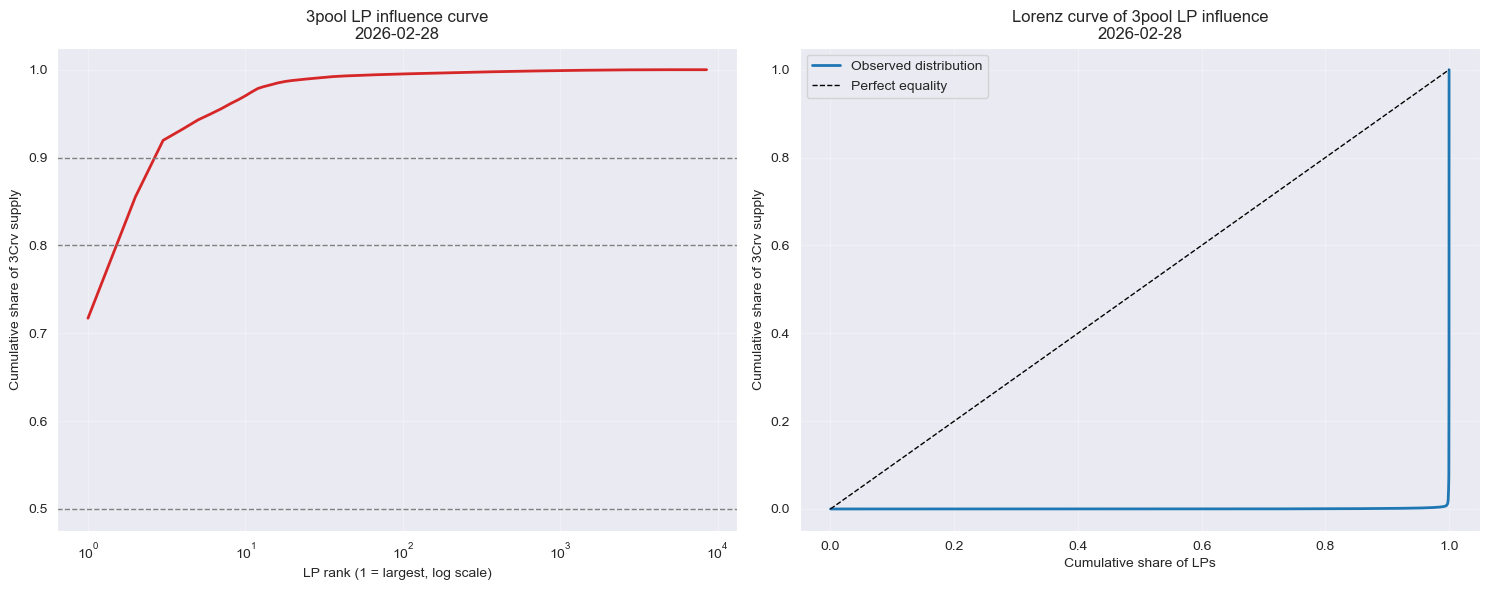

Saved chart: 3crv_lp_influence_curves_all.png
Saved EOA snapshot: 3crv_lp_influence_snapshot_eoa.csv

EOA HOLDERS ONLY
Number of holders: 7,543
Top 1 share:  97.3273%
Top 5 share:  99.0592%
Top 10 share: 99.1846%
Top 20 share: 99.2814%
 rank                                    account  balance_3crv  share_supply  liquidity_claim_usd address_type
    1 0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705  1.119535e+08      0.973273         1.119535e+08          EOA
    2 0x52e1d37d4fb26e125f49c5255d6bd9b0ee27d642  9.200540e+05      0.007999         9.200538e+05          EOA
    3 0x4486083589a063ddef47ee2e4467b5236c508fde  8.916992e+05      0.007752         8.916989e+05          EOA
    4 0x4ad70206bc254776485672959bed9ef71ece02d4  1.315555e+05      0.001144         1.315555e+05          EOA
    5 0xf417860b53d52f7ac2f1012cf097d97a5d748ab5  4.891071e+04      0.000425         4.891069e+04          EOA
    6 0x10e807e524e70f050221c58f452229ed52ece651  3.638947e+04      0.000316         3.638946e+04 

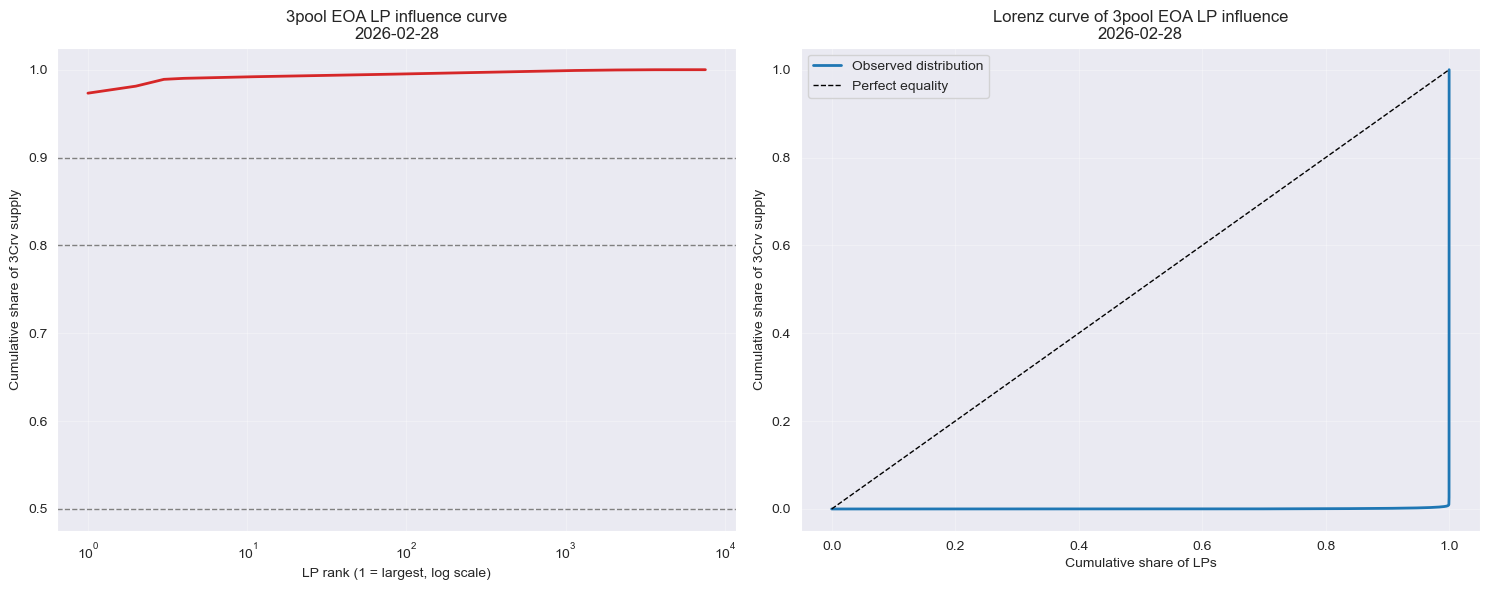

Saved chart: 3crv_lp_influence_curves_eoa.png


In [6]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from dotenv import load_dotenv

load_dotenv()

ZERO = "0x0000000000000000000000000000000000000000"

OUT_EVENTS = "3crv_transfer_events_full.csv"
TVL_FILE = "curve_3pool_liquidity_daily.csv"

OUT_SNAPSHOT_ALL = "3crv_lp_influence_snapshot_all.csv"
OUT_SNAPSHOT_EOA = "3crv_lp_influence_snapshot_eoa.csv"
OUT_CLASSIFIED = "3crv_lp_holders_classified.csv"
OUT_PNG_ALL = "3crv_lp_influence_curves_all.png"
OUT_PNG_EOA = "3crv_lp_influence_curves_eoa.png"

TARGET_DATE = "2026-02-28"

RPC_URL = os.getenv("ETH_RPC_URL")
if not RPC_URL:
    raise RuntimeError("Missing RPC_URL in environment (.env).")

def load_events(path):
    if not os.path.exists(path):
        raise RuntimeError(f"Missing file: {path}")

    events = pd.read_csv(path)

    required_cols = ["blockNumber", "timestamp", "logIndex", "from", "to", "value_raw"]
    missing = [c for c in required_cols if c not in events.columns]
    if missing:
        raise RuntimeError(f"Missing required columns in {path}: {missing}")

    events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True, errors="coerce")
    events["blockNumber"] = pd.to_numeric(events["blockNumber"], errors="coerce")
    events["logIndex"] = pd.to_numeric(events["logIndex"], errors="coerce")
    events["value_raw"] = pd.to_numeric(events["value_raw"], errors="coerce")
    events["from"] = events["from"].astype(str).str.lower()
    events["to"] = events["to"].astype(str).str.lower()

    if "value_3crv" in events.columns:
        events["value_3crv"] = pd.to_numeric(events["value_3crv"], errors="coerce")
    else:
        events["value_3crv"] = events["value_raw"] / 1e18

    events = (
        events.dropna(subset=["timestamp", "blockNumber", "logIndex", "from", "to", "value_3crv"])
              .sort_values(["blockNumber", "logIndex"])
              .reset_index(drop=True)
    )

    if events.empty:
        raise RuntimeError("No usable transfer events found after cleaning.")

    return events

def load_monthly_tvl(path):
    if not os.path.exists(path):
        return None

    tvl = pd.read_csv(path)

    if "date" in tvl.columns:
        tvl["date"] = pd.to_datetime(tvl["date"], utc=True, errors="coerce")
    elif "timestamp" in tvl.columns:
        tvl["date"] = pd.to_datetime(tvl["timestamp"], utc=True, errors="coerce")
    else:
        return None

    if "totalValueLockedUSD" not in tvl.columns:
        return None

    tvl["totalValueLockedUSD"] = pd.to_numeric(tvl["totalValueLockedUSD"], errors="coerce")
    tvl = tvl.dropna(subset=["date", "totalValueLockedUSD"]).copy()

    tvl["month_end"] = tvl["date"].dt.to_period("M").dt.to_timestamp(how="end")
    if tvl["month_end"].dt.tz is None:
        tvl["month_end"] = tvl["month_end"].dt.tz_localize("UTC")
    else:
        tvl["month_end"] = tvl["month_end"].dt.tz_convert("UTC")

    tvl_monthly = (
        tvl.sort_values("date")
           .groupby("month_end", as_index=False)
           .tail(1)[["month_end", "totalValueLockedUSD"]]
           .rename(columns={"month_end": "date"})
           .reset_index(drop=True)
    )
    return tvl_monthly

def build_month_end_snapshots(events):
    start_month = events["timestamp"].min().to_period("M").to_timestamp(how="end")
    end_month = events["timestamp"].max().to_period("M").to_timestamp(how="end")

    if start_month.tzinfo is None:
        start_month = start_month.tz_localize("UTC")
    else:
        start_month = start_month.tz_convert("UTC")

    if end_month.tzinfo is None:
        end_month = end_month.tz_localize("UTC")
    else:
        end_month = end_month.tz_convert("UTC")

    month_ends = pd.date_range(start_month, end_month, freq="M", tz="UTC")

    balances = defaultdict(float)
    total_supply = 0.0
    event_idx = 0
    n_events = len(events)

    snapshots = {}

    for month_end in month_ends:
        while event_idx < n_events and events.loc[event_idx, "timestamp"] <= month_end:
            fr = events.loc[event_idx, "from"]
            to = events.loc[event_idx, "to"]
            val = float(events.loc[event_idx, "value_3crv"])

            if fr == ZERO:
                total_supply += val
            else:
                balances[fr] -= val
                if abs(balances[fr]) < 1e-18:
                    balances.pop(fr, None)

            if to == ZERO:
                total_supply -= val
            else:
                balances[to] += val

            event_idx += 1

        positive = {a: b for a, b in balances.items() if b > 1e-12}

        if len(positive) == 0 or total_supply <= 0:
            snapshots[month_end] = pd.DataFrame(columns=["account", "balance_3crv", "share_supply"])
            continue

        snap = (
            pd.DataFrame({
                "account": list(positive.keys()),
                "balance_3crv": list(positive.values())
            })
            .sort_values("balance_3crv", ascending=False)
            .reset_index(drop=True)
        )

        snap["share_supply"] = snap["balance_3crv"] / total_supply
        snap["date"] = month_end
        snap["rank"] = np.arange(1, len(snap) + 1)
        snap["cum_share_topdown"] = snap["share_supply"].cumsum()
        snap["cum_lp_share_topdown"] = snap["rank"] / len(snap)

        snapshots[month_end] = snap

    return snapshots

def normalize_target_date(target_date, snapshots):
    available_dates = sorted(snapshots.keys())
    if not available_dates:
        raise RuntimeError("No month-end snapshots could be constructed.")

    if target_date is None:
        return available_dates[-1]

    d = pd.Timestamp(target_date)
    if d.tzinfo is None:
        d = d.tz_localize("UTC")
    else:
        d = d.tz_convert("UTC")

    d = d.to_period("M").to_timestamp(how="end")
    if d.tzinfo is None:
        d = d.tz_localize("UTC")
    else:
        d = d.tz_convert("UTC")

    if d not in snapshots:
        raise RuntimeError(f"Target month {d} not found in available snapshots.")

    return d

def get_code(address, rpc_url=RPC_URL):
    payload = {
        "jsonrpc": "2.0",
        "method": "eth_getCode",
        "params": [address, "latest"],
        "id": 1
    }
    r = requests.post(rpc_url, json=payload, timeout=30)
    r.raise_for_status()
    j = r.json()
    if "result" not in j:
        raise RuntimeError(f"eth_getCode error for {address}: {j}")
    return j["result"]

def classify_address(address, rpc_url=RPC_URL):
    code = get_code(address, rpc_url=rpc_url)
    if code in ["0x", "0x0", "", None]:
        return "EOA"
    return "SMART_CONTRACT"

def classify_addresses(df, sleep_sec=0.05):
    unique_accounts = df["account"].dropna().astype(str).str.lower().unique().tolist()
    rows = []

    for i, addr in enumerate(unique_accounts, start=1):
        try:
            address_type = classify_address(addr)
        except Exception as e:
            address_type = f"ERROR: {str(e)[:120]}"
        rows.append({"account": addr, "address_type": address_type})
        if i % 100 == 0:
            print(f"Classified {i:,} / {len(unique_accounts):,} addresses")
        time.sleep(sleep_sec)

    return pd.DataFrame(rows)

def attach_tvl(snap, tvl_monthly, target_date):
    snap = snap.copy()
    if tvl_monthly is not None:
        tvl_row = tvl_monthly.loc[tvl_monthly["date"] == target_date]
        if not tvl_row.empty:
            tvl_usd = float(tvl_row["totalValueLockedUSD"].iloc[0])
            snap["totalValueLockedUSD"] = tvl_usd
            snap["liquidity_claim_usd"] = snap["share_supply"] * tvl_usd
        else:
            snap["totalValueLockedUSD"] = np.nan
            snap["liquidity_claim_usd"] = np.nan
    else:
        snap["totalValueLockedUSD"] = np.nan
        snap["liquidity_claim_usd"] = np.nan
    return snap

def prepare_curves(df):
    df = df.copy().sort_values("balance_3crv", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)
    df["cum_share_topdown"] = df["share_supply"].cumsum()
    df["cum_lp_share_topdown"] = df["rank"] / len(df)

    lorenz = df[["account", "balance_3crv", "share_supply"]].sort_values("balance_3crv", ascending=True).reset_index(drop=True)
    lorenz["cum_lp_share"] = np.arange(1, len(lorenz) + 1) / len(lorenz)
    lorenz["cum_liquidity_share"] = lorenz["share_supply"].cumsum()

    return df, lorenz

def plot_curves(df, lorenz, target_date, title_prefix, out_png):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].plot(df["rank"], df["cum_share_topdown"], color="tab:red", lw=2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("LP rank (1 = largest, log scale)")
    axes[0].set_ylabel("Cumulative share of 3Crv supply")
    axes[0].set_title(f"{title_prefix} influence curve\n{target_date.date()}")
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0.5, color="gray", ls="--", lw=1)
    axes[0].axhline(0.8, color="gray", ls="--", lw=1)
    axes[0].axhline(0.9, color="gray", ls="--", lw=1)

    axes[1].plot(
        np.r_[0, lorenz["cum_lp_share"].values],
        np.r_[0, lorenz["cum_liquidity_share"].values],
        color="tab:blue",
        lw=2,
        label="Observed distribution"
    )
    axes[1].plot([0, 1], [0, 1], color="black", ls="--", lw=1, label="Perfect equality")
    axes[1].set_xlabel("Cumulative share of LPs")
    axes[1].set_ylabel("Cumulative share of 3Crv supply")
    axes[1].set_title(f"Lorenz curve of {title_prefix} influence\n{target_date.date()}")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(out_png, dpi=180)
    plt.show()

def print_summary(name, df):
    if df.empty:
        print(f"{name}: no holders")
        return

    top1 = df["share_supply"].head(1).sum()
    top5 = df["share_supply"].head(5).sum()
    top10 = df["share_supply"].head(10).sum()
    top20 = df["share_supply"].head(20).sum()

    print(f"\n{name}")
    print(f"Number of holders: {len(df):,}")
    print(f"Top 1 share:  {top1:.4%}")
    print(f"Top 5 share:  {top5:.4%}")
    print(f"Top 10 share: {top10:.4%}")
    print(f"Top 20 share: {top20:.4%}")

    cols = ["rank", "account", "balance_3crv", "share_supply"]
    if "liquidity_claim_usd" in df.columns:
        cols.append("liquidity_claim_usd")
    if "address_type" in df.columns:
        cols.append("address_type")

    print(df[cols].head(10).to_string(index=False))

events = load_events(OUT_EVENTS)
tvl_monthly = load_monthly_tvl(TVL_FILE)
snapshots = build_month_end_snapshots(events)
target_date = normalize_target_date(TARGET_DATE, snapshots)

snap_all = snapshots[target_date].copy()
if snap_all.empty:
    raise RuntimeError(f"No holders found at {target_date}.")

snap_all = attach_tvl(snap_all, tvl_monthly, target_date)

print(f"Snapshot date: {target_date}")
print(f"Total holders before classification: {len(snap_all):,}")

# classify all month-end holders
classified = classify_addresses(snap_all)
classified.to_csv(OUT_CLASSIFIED, index=False)
print(f"Saved classified accounts: {OUT_CLASSIFIED}")

snap_all = snap_all.merge(classified, on="account", how="left")
snap_all.to_csv(OUT_SNAPSHOT_ALL, index=False)
print(f"Saved full snapshot: {OUT_SNAPSHOT_ALL}")

# all holders curves
snap_all_curves, lorenz_all = prepare_curves(snap_all)
print_summary("ALL HOLDERS", snap_all_curves)
plot_curves(snap_all_curves, lorenz_all, target_date, "3pool LP", OUT_PNG_ALL)
print(f"Saved chart: {OUT_PNG_ALL}")

# EOA-only curves
snap_eoa = snap_all[snap_all["address_type"] == "EOA"].copy()

if snap_eoa.empty:
    raise RuntimeError("No EOAs found in the selected month-end snapshot.")

# For EOA-only influence, renormalize shares within the EOA subset
eoa_total_balance = snap_eoa["balance_3crv"].sum()
snap_eoa["share_supply"] = snap_eoa["balance_3crv"] / eoa_total_balance

if "totalValueLockedUSD" in snap_eoa.columns and snap_eoa["totalValueLockedUSD"].notna().any():
    tvl_usd = float(snap_eoa["totalValueLockedUSD"].dropna().iloc[0])
    snap_eoa["liquidity_claim_usd"] = snap_eoa["balance_3crv"] / snap_all["balance_3crv"].sum() * tvl_usd

snap_eoa_curves, lorenz_eoa = prepare_curves(snap_eoa)
snap_eoa_curves.to_csv(OUT_SNAPSHOT_EOA, index=False)
print(f"Saved EOA snapshot: {OUT_SNAPSHOT_EOA}")

print_summary("EOA HOLDERS ONLY", snap_eoa_curves)
plot_curves(snap_eoa_curves, lorenz_eoa, target_date, "3pool EOA LP", OUT_PNG_EOA)
print(f"Saved chart: {OUT_PNG_EOA}")



Removed top EOA:
account         0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705
balance_3crv                              111953508.959916
share_supply                                      0.717128
Saved EOA snapshot excluding top 1: 3crv_lp_influence_snapshot_eoa_ex_top1.csv

EOA HOLDERS EXCLUDING TOP 1 EOA
Number of holders: 7,542
Top 1 share:  29.9264%
Top 5 share:  65.9840%
Top 10 share: 70.0777%
Top 20 share: 73.3992%
 rank                                    account  balance_3crv  share_supply  liquidity_claim_usd address_type
    1 0x52e1d37d4fb26e125f49c5255d6bd9b0ee27d642 920054.019236      0.299264        920053.750251          EOA
    2 0x4486083589a063ddef47ee2e4467b5236c508fde 891699.168855      0.290041        891698.908160          EOA
    3 0x4ad70206bc254776485672959bed9ef71ece02d4 131555.537320      0.042791        131555.498858          EOA
    4 0xf417860b53d52f7ac2f1012cf097d97a5d748ab5  48910.707392      0.015909         48910.693092          EOA
    5 0x10e807e524e70

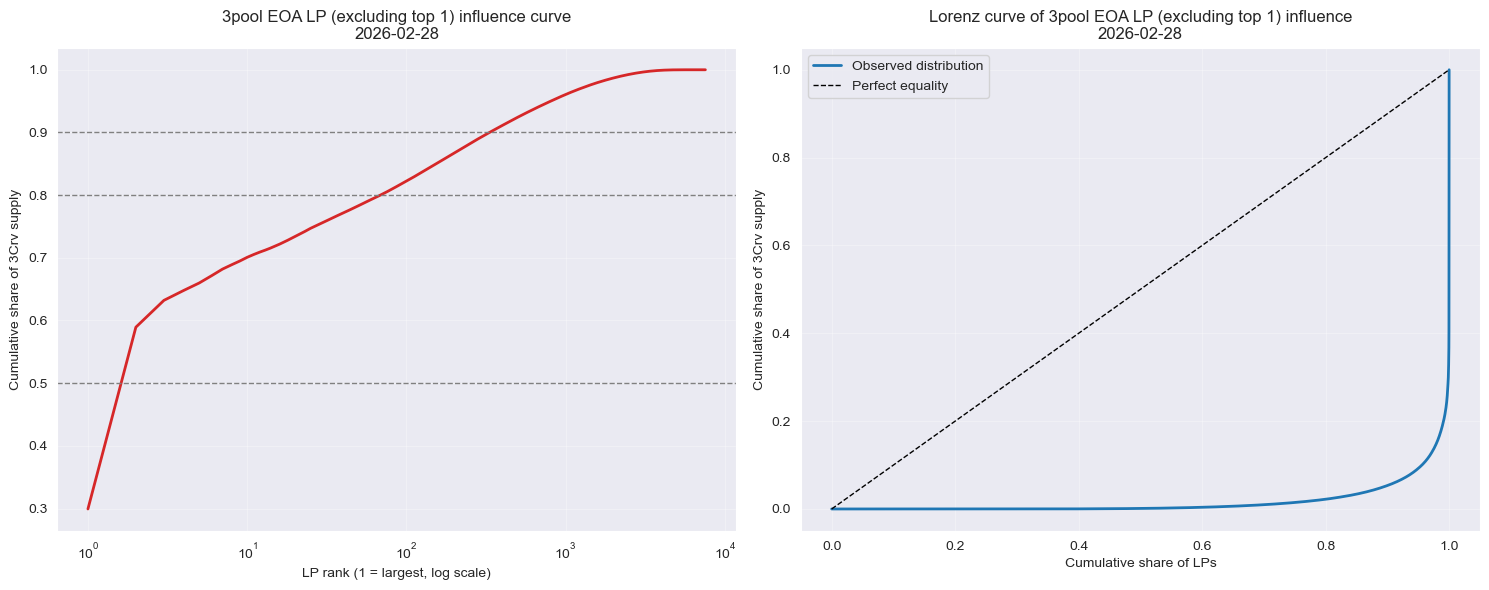

Saved chart: 3crv_lp_influence_curves_eoa_ex_top1.png


In [7]:
OUT_SNAPSHOT_EOA_EX_TOP1 = "3crv_lp_influence_snapshot_eoa_ex_top1.csv"
OUT_PNG_EOA_EX_TOP1 = "3crv_lp_influence_curves_eoa_ex_top1.png"

# EOA-only curves
snap_eoa = snap_all[snap_all["address_type"] == "EOA"].copy()

if snap_eoa.empty:
    raise RuntimeError("No EOAs found in the selected month-end snapshot.")

# sort EOAs by influence
snap_eoa = snap_eoa.sort_values("balance_3crv", ascending=False).reset_index(drop=True)

# identify and remove the most influential EOA
top_eoa_removed = snap_eoa.iloc[0].copy()
snap_eoa_ex_top1 = snap_eoa.iloc[1:].copy().reset_index(drop=True)

if snap_eoa_ex_top1.empty:
    raise RuntimeError("No EOAs remain after excluding the top EOA.")

print("\nRemoved top EOA:")
print(top_eoa_removed[["account", "balance_3crv", "share_supply"]].to_string())

# Renormalize shares within the remaining EOA subset
remaining_eoa_total_balance = snap_eoa_ex_top1["balance_3crv"].sum()
snap_eoa_ex_top1["share_supply"] = snap_eoa_ex_top1["balance_3crv"] / remaining_eoa_total_balance

# Keep liquidity claim in USD relative to the whole pool TVL
if "totalValueLockedUSD" in snap_eoa_ex_top1.columns and snap_eoa_ex_top1["totalValueLockedUSD"].notna().any():
    tvl_usd = float(snap_eoa_ex_top1["totalValueLockedUSD"].dropna().iloc[0])
    snap_eoa_ex_top1["liquidity_claim_usd"] = (
        snap_eoa_ex_top1["balance_3crv"] / snap_all["balance_3crv"].sum()
    ) * tvl_usd

snap_eoa_ex_top1_curves, lorenz_eoa_ex_top1 = prepare_curves(snap_eoa_ex_top1)
snap_eoa_ex_top1_curves.to_csv(OUT_SNAPSHOT_EOA_EX_TOP1, index=False)
print(f"Saved EOA snapshot excluding top 1: {OUT_SNAPSHOT_EOA_EX_TOP1}")

print_summary("EOA HOLDERS EXCLUDING TOP 1 EOA", snap_eoa_ex_top1_curves)
plot_curves(
    snap_eoa_ex_top1_curves,
    lorenz_eoa_ex_top1,
    target_date,
    "3pool EOA LP (excluding top 1)",
    OUT_PNG_EOA_EX_TOP1
)
print(f"Saved chart: {OUT_PNG_EOA_EX_TOP1}")


In [9]:
import os
import numpy as np
import pandas as pd

ZERO = "0x0000000000000000000000000000000000000000"

OUT_EVENTS = "3crv_transfer_events_full.csv"
OUT_CLASSIFIED = "3crv_lp_holders_classified.csv"
OUT_SNAPSHOT_ALL = "3crv_lp_influence_snapshot_all.csv"

OUT_EOA_ACTIVITY = "3crv_eoa_activity_stats.csv"
OUT_TOP_ACTIVE_EOAS = "3crv_top_active_eoas.csv"

# -----------------------------
# Load data
# -----------------------------
events = pd.read_csv(OUT_EVENTS)
classified = pd.read_csv(OUT_CLASSIFIED)

events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True, errors="coerce")
events["blockNumber"] = pd.to_numeric(events["blockNumber"], errors="coerce")
events["logIndex"] = pd.to_numeric(events["logIndex"], errors="coerce")
events["from"] = events["from"].astype(str).str.lower()
events["to"] = events["to"].astype(str).str.lower()

if "value_3crv" in events.columns:
    events["value_3crv"] = pd.to_numeric(events["value_3crv"], errors="coerce")
else:
    events["value_3crv"] = pd.to_numeric(events["value_raw"], errors="coerce") / 1e18

events = (
    events.dropna(subset=["timestamp", "blockNumber", "logIndex", "from", "to", "value_3crv"])
          .sort_values(["blockNumber", "logIndex"])
          .reset_index(drop=True)
)

classified["account"] = classified["account"].astype(str).str.lower()
classified = classified.drop_duplicates("account")

# optional: latest snapshot, useful to merge current influence with activity
snap_all = None
if os.path.exists(OUT_SNAPSHOT_ALL):
    snap_all = pd.read_csv(OUT_SNAPSHOT_ALL)
    snap_all["account"] = snap_all["account"].astype(str).str.lower()

# -----------------------------
# Build address-level activity
# -----------------------------
sent = (
    events.loc[events["from"] != ZERO]
    .groupby("from")
    .agg(
        sent_tx_count=("value_3crv", "size"),
        sent_3crv=("value_3crv", "sum"),
        first_sent=("timestamp", "min"),
        last_sent=("timestamp", "max"),
    )
    .reset_index()
    .rename(columns={"from": "account"})
)

recv = (
    events.loc[events["to"] != ZERO]
    .groupby("to")
    .agg(
        recv_tx_count=("value_3crv", "size"),
        recv_3crv=("value_3crv", "sum"),
        first_recv=("timestamp", "min"),
        last_recv=("timestamp", "max"),
    )
    .reset_index()
    .rename(columns={"to": "account"})
)

activity = sent.merge(recv, on="account", how="outer")

for col in ["sent_tx_count", "sent_3crv", "recv_tx_count", "recv_3crv"]:
    activity[col] = pd.to_numeric(activity[col], errors="coerce").fillna(0)

activity["transfer_count"] = activity["sent_tx_count"] + activity["recv_tx_count"]
activity["abs_flow_3crv"] = activity["sent_3crv"] + activity["recv_3crv"]
activity["net_flow_3crv"] = activity["recv_3crv"] - activity["sent_3crv"]

activity["first_activity"] = activity[["first_sent", "first_recv"]].min(axis=1)
activity["last_activity"] = activity[["last_sent", "last_recv"]].max(axis=1)
activity["active_span_days"] = (
    (activity["last_activity"] - activity["first_activity"]).dt.total_seconds() / 86400.0
)

# active days and months based on any appearance in from/to
outgoing_days = events.loc[events["from"] != ZERO, ["from", "timestamp"]].copy()
outgoing_days["day"] = outgoing_days["timestamp"].dt.floor("D")
outgoing_days = outgoing_days.rename(columns={"from": "account"})[["account", "day"]]

incoming_days = events.loc[events["to"] != ZERO, ["to", "timestamp"]].copy()
incoming_days["day"] = incoming_days["timestamp"].dt.floor("D")
incoming_days = incoming_days.rename(columns={"to": "account"})[["account", "day"]]

all_days = pd.concat([outgoing_days, incoming_days], ignore_index=True).drop_duplicates()
active_days = all_days.groupby("account").size().reset_index(name="active_days")

outgoing_months = events.loc[events["from"] != ZERO, ["from", "timestamp"]].copy()
outgoing_months["month"] = outgoing_months["timestamp"].dt.to_period("M").astype(str)
outgoing_months = outgoing_months.rename(columns={"from": "account"})[["account", "month"]]

incoming_months = events.loc[events["to"] != ZERO, ["to", "timestamp"]].copy()
incoming_months["month"] = incoming_months["timestamp"].dt.to_period("M").astype(str)
incoming_months = incoming_months.rename(columns={"to": "account"})[["account", "month"]]

all_months = pd.concat([outgoing_months, incoming_months], ignore_index=True).drop_duplicates()
active_months = all_months.groupby("account").size().reset_index(name="active_months")

activity = activity.merge(active_days, on="account", how="left")
activity = activity.merge(active_months, on="account", how="left")
activity["active_days"] = activity["active_days"].fillna(0).astype(int)
activity["active_months"] = activity["active_months"].fillna(0).astype(int)

# -----------------------------
# Merge classification
# -----------------------------
activity = activity.merge(classified, on="account", how="left")
activity["address_type"] = activity["address_type"].fillna("UNKNOWN")

# optional: merge current snapshot to relate activity to current influence
if snap_all is not None:
    keep_cols = ["account", "balance_3crv", "share_supply", "liquidity_claim_usd"]
    keep_cols = [c for c in keep_cols if c in snap_all.columns]
    activity = activity.merge(snap_all[keep_cols], on="account", how="left")

# -----------------------------
# EOA-only stats
# -----------------------------
eoa = activity[activity["address_type"] == "EOA"].copy()

if eoa.empty:
    raise RuntimeError("No EOAs found in classification file.")

summary = {
    "n_eoas": len(eoa),
    "mean_transfer_count": eoa["transfer_count"].mean(),
    "median_transfer_count": eoa["transfer_count"].median(),
    "mean_abs_flow_3crv": eoa["abs_flow_3crv"].mean(),
    "median_abs_flow_3crv": eoa["abs_flow_3crv"].median(),
    "mean_active_span_days": eoa["active_span_days"].mean(),
    "median_active_span_days": eoa["active_span_days"].median(),
    "mean_active_days": eoa["active_days"].mean(),
    "median_active_days": eoa["active_days"].median(),
    "mean_active_months": eoa["active_months"].mean(),
    "median_active_months": eoa["active_months"].median(),
}

print("\nEOA activity summary:")
for k, v in summary.items():
    if isinstance(v, (int, np.integer)):
        print(f"{k}: {v:,}")
    else:
        print(f"{k}: {v:,.4f}")

# -----------------------------
# Top active EOAs
# -----------------------------
top_by_flow = eoa.sort_values("abs_flow_3crv", ascending=False).copy()
top_by_count = eoa.sort_values("transfer_count", ascending=False).copy()
top_by_span = eoa.sort_values("active_span_days", ascending=False).copy()

show_cols = [
    "account",
    "transfer_count",
    "abs_flow_3crv",
    "net_flow_3crv",
    "active_days",
    "active_months",
    "active_span_days",
    "balance_3crv",
    "share_supply",
    "liquidity_claim_usd",
]
show_cols = [c for c in show_cols if c in eoa.columns]

print("\nTop 20 EOAs by absolute 3Crv flow:")
print(top_by_flow[show_cols].head(20).to_string(index=False))

print("\nTop 20 EOAs by transfer count:")
print(top_by_count[show_cols].head(20).to_string(index=False))

print("\nTop 20 EOAs by active span:")
print(top_by_span[show_cols].head(20).to_string(index=False))

# save one unified ranking table
top_active = top_by_flow.copy()
top_active["rank_by_abs_flow"] = np.arange(1, len(top_active) + 1)

rank_count = top_by_count[["account"]].copy()
rank_count["rank_by_transfer_count"] = np.arange(1, len(rank_count) + 1)

rank_span = top_by_span[["account"]].copy()
rank_span["rank_by_active_span"] = np.arange(1, len(rank_span) + 1)

top_active = top_active.merge(rank_count, on="account", how="left")
top_active = top_active.merge(rank_span, on="account", how="left")

eoa.to_csv(OUT_EOA_ACTIVITY, index=False)
top_active.to_csv(OUT_TOP_ACTIVE_EOAS, index=False)

print(f"\nSaved EOA activity stats: {OUT_EOA_ACTIVITY}")
print(f"Saved top active EOAs:   {OUT_TOP_ACTIVE_EOAS}")


/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/1623320834.py:103: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  outgoing_months["month"] = outgoing_months["timestamp"].dt.to_period("M").astype(str)
/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_20437/1623320834.py:107: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  incoming_months["month"] = incoming_months["timestamp"].dt.to_period("M").astype(str)



EOA activity summary:
n_eoas: 7,543
mean_transfer_count: 8.1588
median_transfer_count: 2.0000
mean_abs_flow_3crv: 960,323.8998
median_abs_flow_3crv: 98.2271
mean_active_span_days: 246.7247
median_active_span_days: 0.7508
mean_active_days: 5.0485
median_active_days: 2.0000
mean_active_months: 3.1193
median_active_months: 1.0000

Top 20 EOAs by absolute 3Crv flow:
                                   account  transfer_count  abs_flow_3crv  net_flow_3crv  active_days  active_months  active_span_days  balance_3crv  share_supply  liquidity_claim_usd
0xead735c299de709eecfd84eaf0632e0d7458c3ca            33.0   5.331179e+08   3.411826e+01           12              5        166.544375  3.411826e+01  2.185474e-07         3.411826e+01
0x99fd1378ca799ed6772fe7bcdc9b30b389518962           225.0   5.013950e+08   0.000000e+00          121             27       1845.040336  3.729610e-09  2.389033e-17         3.729610e-09
0xa7888f85bd76deef3bd03d4dbcf57765a49883b3           173.0   2.775542e+08   2.8525

In [ ]:
import os
import time
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

ETHERSCAN_API_KEY = os.getenv("ETHERSCAN_API_KEY")
if not ETHERSCAN_API_KEY:
    raise RuntimeError("Missing ETHERSCAN_API_KEY in environment (.env).")

TOKEN = "0x6c3f90f043a72fa612cbac8115ee7e52bde6e490".lower()  # 3Crv
TRANSFER_TOPIC0 = "0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"

ETHERSCAN_URL = "https://api.etherscan.io/v2/api"
CHAIN_ID = 1
OFFSET = 1000
START_BLOCK = 10800000
INITIAL_CHUNK_SIZE = 50000

OUT_EVENTS = "3crv_transfer_events_full.parquet"


def get_latest_block():
    params = {
        "chainid": CHAIN_ID,
        "module": "proxy",
        "action": "eth_blockNumber",
        "apikey": ETHERSCAN_API_KEY,
    }
    r = requests.get(ETHERSCAN_URL, params=params, timeout=60)
    r.raise_for_status()
    j = r.json()
    if "result" not in j:
        raise RuntimeError(f"Could not fetch latest block: {j}")
    return int(j["result"], 16)


def etherscan_get_logs(from_block, to_block, page=1, offset=1000, retries=5):
    params = {
        "chainid": CHAIN_ID,
        "module": "logs",
        "action": "getLogs",
        "fromBlock": from_block,
        "toBlock": to_block,
        "address": TOKEN,
        "topic0": TRANSFER_TOPIC0,
        "page": page,
        "offset": offset,
        "apikey": ETHERSCAN_API_KEY,
    }

    for attempt in range(retries):
        r = requests.get(ETHERSCAN_URL, params=params, timeout=60)
        r.raise_for_status()
        j = r.json()

        result = j.get("result")
        message = str(j.get("message", ""))

        if isinstance(result, list):
            return result

        if result == "No records found" or "No records found" in message:
            return []

        txt = str(j)
        if "Result window is too large" in txt:
            raise ValueError("WINDOW_TOO_LARGE")

        if attempt < retries - 1:
            time.sleep(1.5 * (attempt + 1))
            continue

        raise RuntimeError(f"Etherscan logs error: {j}")


def fetch_logs_for_range(from_block, to_block):
    out = []
    page = 1

    while True:
        batch = etherscan_get_logs(
            from_block=from_block,
            to_block=to_block,
            page=page,
            offset=OFFSET,
        )

        if not batch:
            break

        out.extend(batch)

        if len(batch) < OFFSET:
            break

        if page * OFFSET >= 10000:
            raise ValueError("WINDOW_TOO_LARGE")

        page += 1
        time.sleep(0.2)

    return out


def fetch_all_transfer_logs(start_block, end_block):
    all_logs = []
    start = start_block
    chunk_size = INITIAL_CHUNK_SIZE

    while start <= end_block:
        end = min(start + chunk_size - 1, end_block)

        while True:
            try:
                batch = fetch_logs_for_range(start, end)
                all_logs.extend(batch)
                print(f"Blocks {start:,}-{end:,}: fetched {len(batch)} logs, total {len(all_logs)}")
                break
            except ValueError as e:
                if str(e) != "WINDOW_TOO_LARGE":
                    raise
                if start >= end:
                    raise RuntimeError(f"Single block window still too large at block {start}")
                end = start + (end - start) // 2
                print(f"Shrinking block range -> {start:,}-{end:,}")

        start = end + 1
        time.sleep(0.2)

    if all_logs:
        tmp = pd.DataFrame(all_logs)
        dedup_cols = [c for c in ["blockNumber", "transactionHash", "logIndex"] if c in tmp.columns]
        if dedup_cols:
            tmp = tmp.drop_duplicates(subset=dedup_cols).reset_index(drop=True)
            all_logs = tmp.to_dict("records")

    return all_logs


def hex_to_int(x, default=0):
    if x is None:
        return default
    if isinstance(x, int):
        return x

    x = str(x).strip().lower()
    if x in {"", "0x", "0x0", "none", "null"}:
        return default

    try:
        return int(x, 16) if x.startswith("0x") else int(x)
    except ValueError:
        return default


def topic_to_address(topic_hex):
    topic_hex = topic_hex.lower().replace("0x", "")
    return "0x" + topic_hex[-40:]


def decode_logs_to_dataframe(logs):
    rows = []

    for lg in logs:
        topics = lg.get("topics", [])
        if len(topics) < 3:
            continue

        rows.append({
            "blockNumber": hex_to_int(lg.get("blockNumber")),
            "timestamp": pd.to_datetime(hex_to_int(lg.get("timeStamp")), unit="s", utc=True),
            "txHash": lg.get("transactionHash"),
            "logIndex": hex_to_int(lg.get("logIndex")),
            "from": topic_to_address(topics[1]).lower(),
            "to": topic_to_address(topics[2]).lower(),
            "value_raw": hex_to_int(lg.get("data", "0x0")),
            "value_3crv": hex_to_int(lg.get("data", "0x0")) / 1e18,
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["blockNumber", "logIndex"]).reset_index(drop=True)

    return df


if __name__ == "__main__":
    end_block = get_latest_block()
    print(f"Downloading 3Crv Transfer logs from block {START_BLOCK:,} to {end_block:,}...")

    logs = fetch_all_transfer_logs(START_BLOCK, end_block)
    if not logs:
        raise RuntimeError("No transfer logs returned.")

    events = decode_logs_to_dataframe(logs)
    if events.empty:
        raise RuntimeError("No decoded transfer events.")

    events.to_csv(OUT_EVENTS, index=False)

    print(f"Saved raw events to: {OUT_EVENTS}")
    print(f"Rows: {len(events):,}")
    print(f"Date range: {events['timestamp'].min()} -> {events['timestamp'].max()}")
